In [ ]:
# =================================================================
# 1. INSTALLATION & ENVIRONMENT SETUP
# =================================================================
!pip install matplotlib scipy h5py
!pip install "numpy<2.0" pysynphot astropy sh

In [ ]:
import os

# Pysynphot requires a data directory environment variable to avoid errors
if 'PYSYN_CDBS' not in os.environ:
    os.makedirs('/content/pysynphot_db', exist_ok=True)
    os.environ['PYSYN_CDBS'] = '/content/pysynphot_db'

In [ ]:
# =================================================================
# 2. IMPORTS
# =================================================================
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterExponent
import matplotlib.ticker as mticker
from numpy import unravel_index
import astropy.units as u
import math
from sh import gunzip
from IPython.display import clear_output
import time
from scipy.ndimage import rotate
from scipy.interpolate import RegularGridInterpolator
import h5py
from pathlib import Path
from matplotlib.patches import Circle
from importlib import reload
import pysynphot
from astropy.io.votable import parse_single_table

In [ ]:
# You will be prompted to sign in for the authorization key to access your Google account
#    Click on the "Go to this URL in  a browser"
#    Click on "Sign in" for the authorization
#    Copy the key (be sure to capture the full key - there may be a scroll bar) and paste the key in the text box and press the return key
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
# =================================================================
# 3. FILE PATHS & DATA LOADING
# =================================================================
# Google top level drive dir
drive_dir = "/content/drive/MyDrive/"
diskmodel_dir = 'Roman_winter_school/SED_disk'
# Disk Model Path
diskmodel_path = os.path.join(drive_dir,diskmodel_dir)
sed_path = os.path.join(diskmodel_path, 'sed_rt.fits')

In [ ]:
if os.path.exists(sed_path):
    with fits.open(sed_path) as hdul:
        # Check header info if you're unsure of structure: hdul.info()

        # Wavelength is usually in the second extension (index 1)
        wav = hdul[1].data

        # Flux components are in the primary HDU (index 0)
        # We use .copy() to ensure the data stays in memory after the file closes
        modelt_flux = hdul[0].data[0].copy()
        star_flux   = hdul[0].data[1].copy()
        sst_flux    = hdul[0].data[2].copy()
        dth_flux    = hdul[0].data[3].copy()

    print(f"✅ Successfully loaded 'wav' and flux arrays. Array shape: {wav.shape}")

    # Now create the pysynphot objects
    modeltotal = pysynphot.ArraySpectrum(wav, modelt_flux.flatten(), name='total-model', fluxunits='flam', waveunits='microns')
    star       = pysynphot.ArraySpectrum(wav, star_flux.flatten(), name='star-model', fluxunits='flam', waveunits='microns')
    scat_light = pysynphot.ArraySpectrum(wav, sst_flux.flatten(), name='sst-model', fluxunits='flam', waveunits='microns')
    dir_th     = pysynphot.ArraySpectrum(wav, dth_flux.flatten(), name='dth-model', fluxunits='flam', waveunits='microns')

else:
    print(f"❌ ERROR: File not found at {sed_path}")

✅ Successfully loaded 'wav' and flux arrays. Array shape: (50,)


In [ ]:
# =================================================================
# 4. PYSYNPHOT SPECTRUM OBJECTS
# =================================================================
# pysynphot handles the waveunits conversion internally
modeltotal = pysynphot.ArraySpectrum(wav, modelt_flux.flatten(), name='total-model', fluxunits='flam', waveunits='microns')
star       = pysynphot.ArraySpectrum(wav, star_flux.flatten(), name='star-model', fluxunits='flam', waveunits='microns')
scat_light = pysynphot.ArraySpectrum(wav, sst_flux.flatten(), name='sst-model', fluxunits='flam', waveunits='microns')
dir_th     = pysynphot.ArraySpectrum(wav, dth_flux.flatten(), name='dth-model', fluxunits='flam', waveunits='microns')

In [ ]:
# =================================================================
# 5. FLUX CONVERSION (F_lambda to F_nu in mJy)
# =================================================================
# Speed of light
c = 2.99792458e14

# Using the standard conversion: F_nu = F_lambda * (lambda^2 / c)
# We multiply by 1e26 to get Jy, then 1e3 for mJy
def to_mjy(spectrum):
    wave_ang = spectrum.wave
    flux_flam = spectrum.flux
    # Conversion to Jy: 1e26 * F_lambda * lambda^2 / c
    # Adding * 1e3 for mJy
    return (1e26 * flux_flam * (wave_ang*1000)) / c

mt_mjy = to_mjy(modeltotal)
st_mjy = to_mjy(star)
scat_mjy = to_mjy(scat_light)
dth_mjy = to_mjy(dir_th)

In [ ]:
# observations from Simbad

obs_wav=[0.35,0.4,0.554,0.64,0.673,0.771,0.9,1.24,1.65,2.16,3.35,4.6,5.03,8.61,11.6,18.4,23.9,61.8,71.4,102,100,160]
obs_flux_jy=np.array([9.03,43.8,45.1,41.9,38.1,19.8,13.4,28.2,20.4,12.9,5.59,5.27,3.74,1.45,1.52,0.921,1.09,0.4,0.226,1.20,0.0975,0.0497])*1000

In [ ]:
# Read VOTable
HD172555_vot = parse_single_table(drive_dir+diskmodel_dir+"/HD172555.vot").to_table()
sed_wav=HD172555_vot['sed_freq'].to(u.micron, equivalencies=u.spectral())
sed_flux=HD172555_vot['sed_flux'].to(u.mJy)
sed_eflux=HD172555_vot['sed_eflux'].to(u.mJy)
# Remove the datapoints with no errorbars (upper limits, etc.)
for i in range(len(sed_wav)):
  if np.isnan(sed_eflux[i]) or sed_eflux[i]<=0.0:
    sed_flux[i]=np.nan


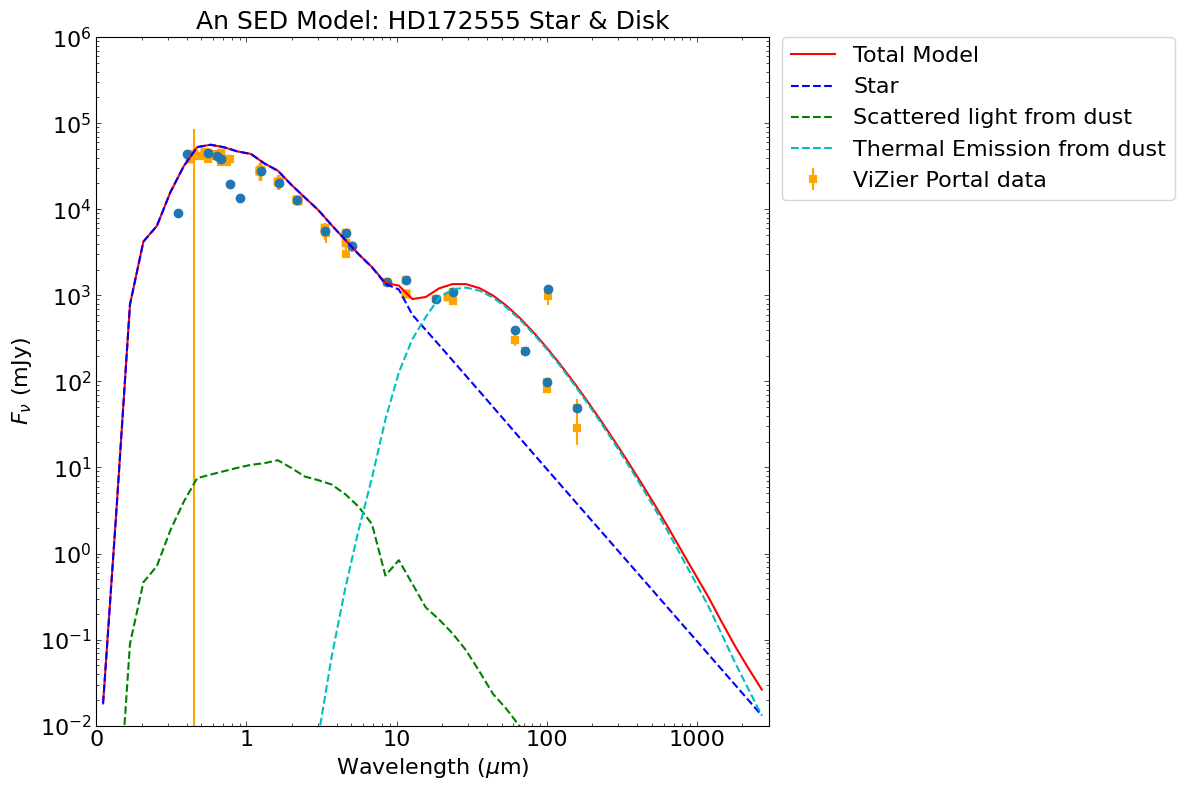

In [ ]:
# =================================================================
# 6. FINAL PLOTTING
# =================================================================
fig = plt.figure(figsize=(12,8))
ax3 = fig.add_subplot(111)

ax3.yaxis.set_ticks_position('both')
ax3.xaxis.set_ticks_position('both')
ax3.minorticks_on()
ax3.tick_params(which='both', direction='in', width=0.5, labelsize=16)

# Plotting (Converting wav to microns for X-axis)
ax3.loglog(wav, mt_mjy, '-', color='r', label='Total Model')
ax3.loglog(wav, st_mjy, '--', color='b', label='Star')
ax3.loglog(wav, scat_mjy, '--', color='g', label='Scattered light from dust')
ax3.loglog(wav, dth_mjy, '--', color='c', label='Thermal Emission from dust')
#ax3.scatter(obs_wav,obs_flux_jy,marker='o')

ax3.errorbar(sed_wav,sed_flux,yerr=sed_eflux,ls='None',marker='s',ms=3, mew=3,\
             label="ViZier Portal data",mfc='orange',mec='orange',ecolor='orange',zorder=0)

ax3.set_ylim(10**-2, 1*10**6)
ax3.set_xlim(0.1, 3000)
ax3.set_ylabel(r'$F_\nu$ (mJy)', fontsize=16)
ax3.set_xlabel(r'Wavelength ($\mu$m)', fontsize=16)
ax3.set_title('An SED Model: HD172555 Star & Disk', fontsize=18)
ax3.legend(loc='upper left', bbox_to_anchor=(1.02, 1),
           fontsize=16, borderaxespad=0., frameon=True)
ax3.xaxis.set_major_formatter(mticker.ScalarFormatter())


plt.tight_layout()
plt.show()